# Análisis 3: Eficiencia de Selecciones
## Más allá de los títulos: ¿quién es realmente eficiente?

**Preguntas a responder:**
1. ¿Qué país tiene el mayor % de victorias en la historia?
2. ¿Quiénes son los "one-hit wonders"?
3. ¿Quiénes son los "always the bridesmaid"?
4. ¿Qué selecciones rinden mejor en knockout que en group stage?

In [1]:
import pandas as pd
import numpy as np
import sys
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('..')
from src.visualization import set_style, plot_team_efficiency, save_figure

set_style()

editions = pd.read_csv('../data/processed/editions_clean.csv')
matches = pd.read_csv('../data/processed/matches_clean.csv')
print('Data loaded successfully')

Data loaded successfully


## Análisis 1: Títulos por país

In [2]:
champion_counts = editions['champion'].value_counts()
display(champion_counts)

champion
Brazil       5
Italy        4
Germany      4
Argentina    3
Uruguay      2
France       2
England      1
Spain        1
Name: count, dtype: int64

C:\Users\migue\AppData\Local\Temp\ipykernel_34296\1706381310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=champion_counts.values, y=champion_counts.index, palette='viridis', ax=ax)


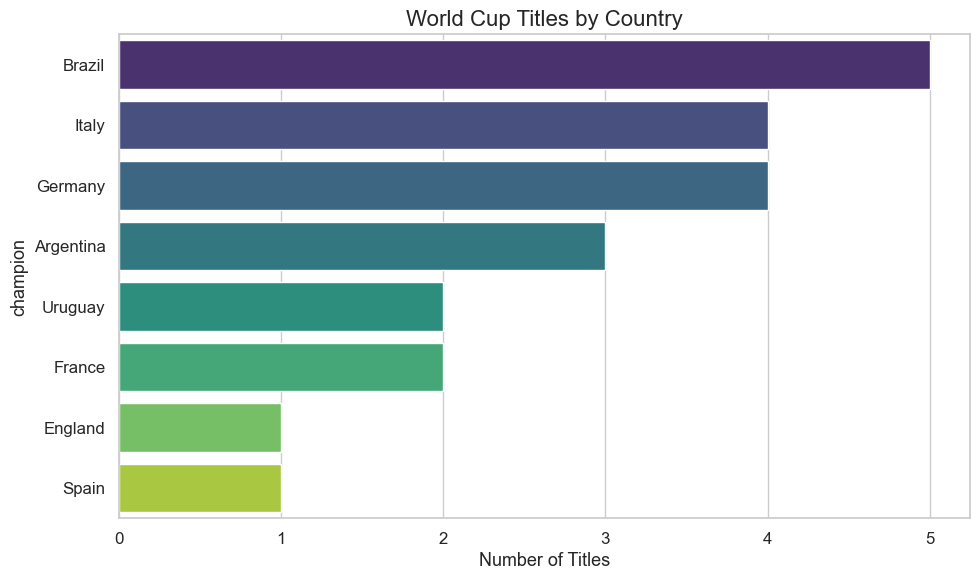

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=champion_counts.values, y=champion_counts.index, palette='viridis', ax=ax)
ax.set_title('World Cup Titles by Country')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

## Análisis 2: Eficiencia (títulos por aparición en top 4)

Figure saved: c:\laragon\www\fifa_world_cup_data\reports\figures\team_efficiency.png


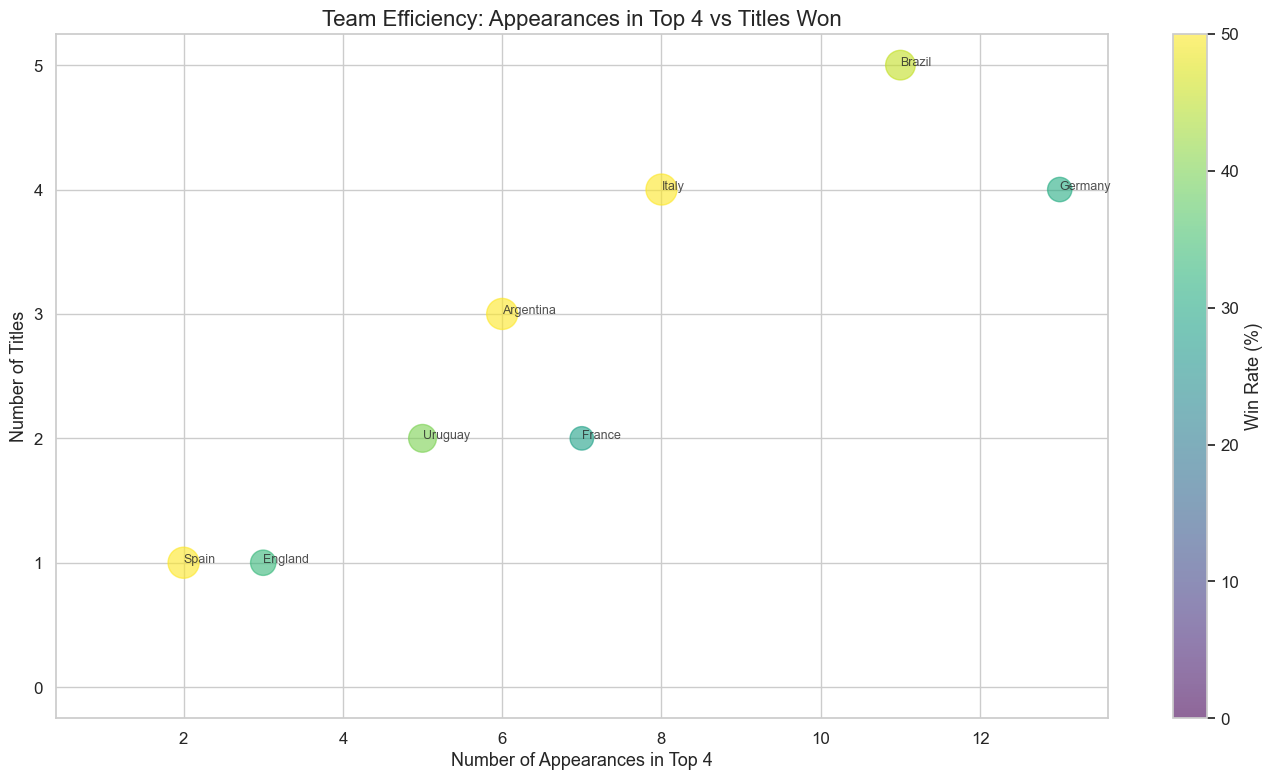

In [4]:
fig = plot_team_efficiency(editions)
save_figure(fig, 'team_efficiency')
plt.show()

## Análisis 3: One-hit wonders

In [5]:
top4 = pd.concat([
    editions[['year', 'champion']].rename(columns={'champion': 'team'}),
    editions[['year', 'runner_up']].rename(columns={'runner_up': 'team'}),
    editions[['year', 'third_place']].rename(columns={'third_place': 'team'}),
    editions[['year', 'fourth_place']].rename(columns={'fourth_place': 'team'})
])
top4_counts = top4['team'].value_counts()
one_hit = top4_counts[top4_counts == 1]
print('One-hit wonders (only 1 top 4 appearance):')
display(one_hit)

One-hit wonders (only 1 top 4 appearance):


team
United States    1
Chile            1
Turkey           1
Russia           1
Bulgaria         1
South Korea      1
Morocco          1
Name: count, dtype: int64

## Conclusiones

**Escribe aquí tus hallazgos.**

- ¿Qué país es el más eficiente?
- ¿Quiénes son los one-hit wonders?
- ¿Quiénes son los always the bridesmaid?